# Elastic differential cross section vs energy — 3D visualization (test)

Reconstructs the elastic (MT2) differential cross section
$d\sigma/d\Omega(\mu,E) = \dfrac{\sigma(E)}{2\pi}\,f(\mu,E)$
directly from an ENDF file and shows it as **3D surfaces** over an incident-energy
band (default 0.85-4 MeV, the Fe-56 elastic angular-distribution tuning range).

Energy is kept at **full native resolution** (no downsampling) so the sharp
fluctuations with energy survive. Three surfaces are shown individually:
angular shape $f(\mu,E)$, absolute $d\sigma/d\Omega$ (linear), and the same in
$\log_{10}$. A short **peak/smoothness summary** counts how many sharp peaks the
cross section has across the range.

Reuses existing kika machinery only: `read_mf4_mt`/`read_mf3_mt`,
`AngularDistribution.evaluate_pdf`, `MF3MT.get_cross_section`,
`cosine_to_angle_degrees`, thesis plotting style.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)
from scipy.signal import find_peaks, peak_widths

from kika.endf.read_endf import read_mf4_mt, read_mf3_mt
from kika.nuclear_data.angular_distribution import AngularDistribution
from kika.exfor.AD_utils import cosine_to_angle_degrees
from kika.plotting.styles import _apply_style_to_rcparams

# ---------------- configuration ----------------
ENDF_FILE = os.environ.get(
    "KIKA_DCS_ENDF",
    "/share_snc/snc/JuanMonleon/ENDF_samples/new_test_80/26-Fe-56g_nominal_mg.endf",
)
MT            = 2          # 2 = elastic
E_MIN_MEV     = 0.85
E_MAX_MEV     = 4.0
N_MU          = 91         # cosine samples across [-1, 1] (angular direction is smooth)
ANGLE_AXIS    = "degrees"  # "degrees" (CM scattering angle) or "mu" (cos theta)
VIEW_ELEV     = 26         # 3D elevation; raise/lower to change the viewpoint
VIEW_AZIM     = -58        # 3D azimuth; e.g. +122 to look from behind (back angles front)

# peak / smoothness summary
PEAK_NPTS      = 6300      # dense sigma(E) sampling for peak finding (~0.5 keV)
PEAK_PROM_FRAC = 0.05      # a peak counts as "sharp" if its prominence exceeds this
                           # fraction of the sigma(E) range in the band
print("file:", ENDF_FILE)

file: /share_snc/snc/JuanMonleon/ENDF_samples/new_test_80/26-Fe-56g_nominal_mg.endf


In [2]:
# ---------------- load + reconstruct on the native energy grid ----------------
mf4 = read_mf4_mt(ENDF_FILE, MT)
mf3 = read_mf3_mt(ENDF_FILE, MT)
ad  = AngularDistribution.from_endf(mf4)

E_all = np.asarray(ad.energies, dtype=float)                 # eV
band  = (E_all >= E_MIN_MEV * 1e6) & (E_all <= E_MAX_MEV * 1e6)
E_grid = E_all[band]                                         # eV, full native grid
E_MeV  = E_grid / 1e6
mu     = np.linspace(-1.0, 1.0, N_MU)

# angular shape f(mu, E): rows = energy, cols = mu  (evaluate at every native energy)
F = np.empty((E_grid.size, mu.size))
for i, e in enumerate(E_grid):
    _, F[i] = ad.evaluate_pdf(e, cosines=mu)

# absolute dsigma/dOmega = sigma(E)/(2 pi) * f(mu, E)
sigma = np.asarray(mf3.get_cross_section(E_grid), dtype=float)   # barns
DCS   = (sigma[:, None] / (2.0 * np.pi)) * F                     # b/sr

# x-axis: CM scattering angle (deg) or cos theta; sort ascending for the surface
if ANGLE_AXIS == "degrees":
    x_raw  = cosine_to_angle_degrees(mu)
    xlabel = r"CM scattering angle $\theta$ (deg)"
else:
    x_raw  = mu
    xlabel = r"$\cos\theta$  ($\mu$)"
order = np.argsort(x_raw)
x     = x_raw[order]
F_x   = F[:, order]
DCS_x = DCS[:, order]
X, Y  = np.meshgrid(x, E_MeV)

# quick physics check: 2*pi*int dcs dmu == sigma, int f dmu == 1
print(f"grid: {E_grid.size} energies (full res) x {mu.size} mu")
print(f"sigma_el band: {sigma.min():.3f} - {sigma.max():.3f} b  |  DCS: {DCS.min():.3f} - {DCS.max():.3f} b/sr")
for e in (1.0e6, 3.0e6):
    _, f = ad.evaluate_pdf(e, cosines=mu)
    print(f"  check E={e/1e6:.1f} MeV: int f dmu={np.trapezoid(f, mu):.4f}, "
          f"2pi int dcs dmu={2*np.pi*np.trapezoid((mf3.get_cross_section(e)/(2*np.pi))*f, mu):.4f} b "
          f"vs sigma={float(mf3.get_cross_section(e)):.4f} b")

grid: 1735 energies (full res) x 91 mu
sigma_el band: 0.356 - 6.797 b  |  DCS: -0.105 - 2.988 b/sr
  check E=1.0 MeV: int f dmu=1.0001, 2pi int dcs dmu=1.1638 b vs sigma=1.1637 b
  check E=3.0 MeV: int f dmu=1.0007, 2pi int dcs dmu=1.8212 b vs sigma=1.8199 b


## Peak / smoothness summary

Approximate: how structured is the elastic cross section across the band? The energy
fluctuations in $d\sigma/d\Omega$ come almost entirely from $\sigma(E)$ (the angular
shape $f$ varies slowly), so peaks are counted on a densely-sampled $\sigma(E)$. A peak
is called *sharp* when its prominence exceeds `PEAK_PROM_FRAC` of the $\sigma$ range.

Elastic sigma(E) over 0.85-4.0 MeV:
  range 0.35-9.10 b (mean 2.33 b)
  ~460 sharp peaks (prominence > 5% of range)
      lower half (<2.42 MeV): ~290   upper half: ~180
  typical sharp-peak width (FWHM): median ~2.0 keV, narrowest ~0.3 keV
  mean |d sigma/dE| = 415 b/MeV
  verdict: highly structured (resonance-dominated), NOT smooth


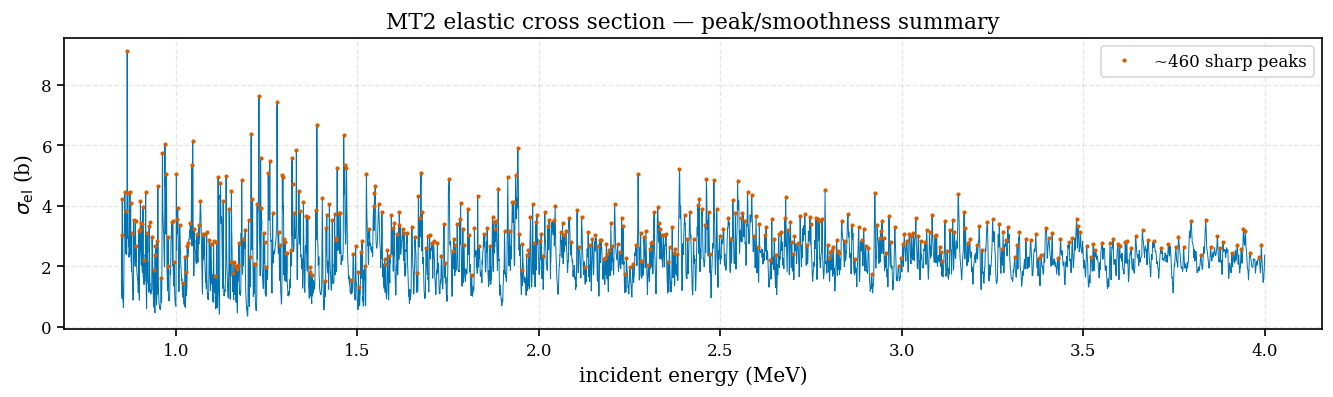

In [3]:
Ed = np.linspace(E_MIN_MEV*1e6, E_MAX_MEV*1e6, PEAK_NPTS)
sd = np.asarray(mf3.get_cross_section(Ed), dtype=float)
rng = sd.max() - sd.min()
de_kev = (Ed[1] - Ed[0]) / 1e3

peaks, props = find_peaks(sd, prominence=PEAK_PROM_FRAC * rng)
fwhm_kev = peak_widths(sd, peaks, rel_height=0.5)[0] * de_kev
mid = 0.5 * (E_MIN_MEV + E_MAX_MEV)
n_lo = int((Ed[peaks] < mid*1e6).sum())
n_hi = len(peaks) - n_lo
roughness = np.abs(np.gradient(sd, Ed/1e6)).mean()

def approx(n): return int(round(n, -1))  # round to nearest 10 -> "approximate"

print(f"Elastic sigma(E) over {E_MIN_MEV}-{E_MAX_MEV} MeV:")
print(f"  range {sd.min():.2f}-{sd.max():.2f} b (mean {sd.mean():.2f} b)")
print(f"  ~{approx(len(peaks))} sharp peaks (prominence > {PEAK_PROM_FRAC:.0%} of range)")
print(f"      lower half (<{mid:.2f} MeV): ~{approx(n_lo)}   upper half: ~{approx(n_hi)}")
print(f"  typical sharp-peak width (FWHM): median ~{np.median(fwhm_kev):.1f} keV, "
      f"narrowest ~{fwhm_kev.min():.1f} keV")
print(f"  mean |d sigma/dE| = {roughness:.0f} b/MeV")
verdict = "highly structured (resonance-dominated), NOT smooth" if len(peaks) > 50 else \
          ("moderately structured" if len(peaks) > 10 else "fairly smooth")
print(f"  verdict: {verdict}")

# compact summary plot: sigma(E) with sharp peaks marked
_apply_style_to_rcparams("default", notebook_mode=True, figsize=(11, 3.2), dpi=120,
                         font_family="serif", projection=None)
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(Ed/1e6, sd, lw=0.6, color="#0173B2")
ax.plot(Ed[peaks]/1e6, sd[peaks], ".", ms=3, color="#D55E00",
        label=f"~{approx(len(peaks))} sharp peaks")
ax.set_xlabel("incident energy (MeV)"); ax.set_ylabel(r"$\sigma_\mathrm{el}$ (b)")
ax.set_title(f"MT{MT} elastic cross section — peak/smoothness summary")
ax.legend(loc="upper right")
plt.show()

## 3D surfaces (full energy resolution)

Same viewpoint for all three; change `VIEW_ELEV` / `VIEW_AZIM` above to rotate, or
`ANGLE_AXIS` to switch between degrees and $\mu$. In a notebook with an interactive
backend (`%matplotlib widget` / `notebook`) these are drag-rotatable.

In [4]:
def surface3d(Z, zlabel, title, cmap="viridis", zlog=False, figsize=(9.5, 7.5)):
    """Single 3D surface over (angle, energy). Margins/labelpad set so no axis label is clipped."""
    _apply_style_to_rcparams("default", notebook_mode=True, figsize=figsize, dpi=120,
                             font_family="serif", projection="3d")
    Zp = np.log10(np.clip(Z, 1e-6, None)) if zlog else Z
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, Zp, cmap=cmap, linewidth=0,
                           antialiased=False, rasterized=True)
    ax.set_xlabel(xlabel, labelpad=16)
    ax.set_ylabel("incident energy (MeV)", labelpad=16)
    ax.set_zlabel(zlabel, labelpad=10)
    ax.set_title(title, pad=10)
    ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)
    ax.tick_params(pad=4)
    fig.subplots_adjust(left=0.04, right=0.94, bottom=0.12, top=0.93)
    fig.colorbar(surf, ax=ax, shrink=0.55, pad=0.10)
    plt.show()

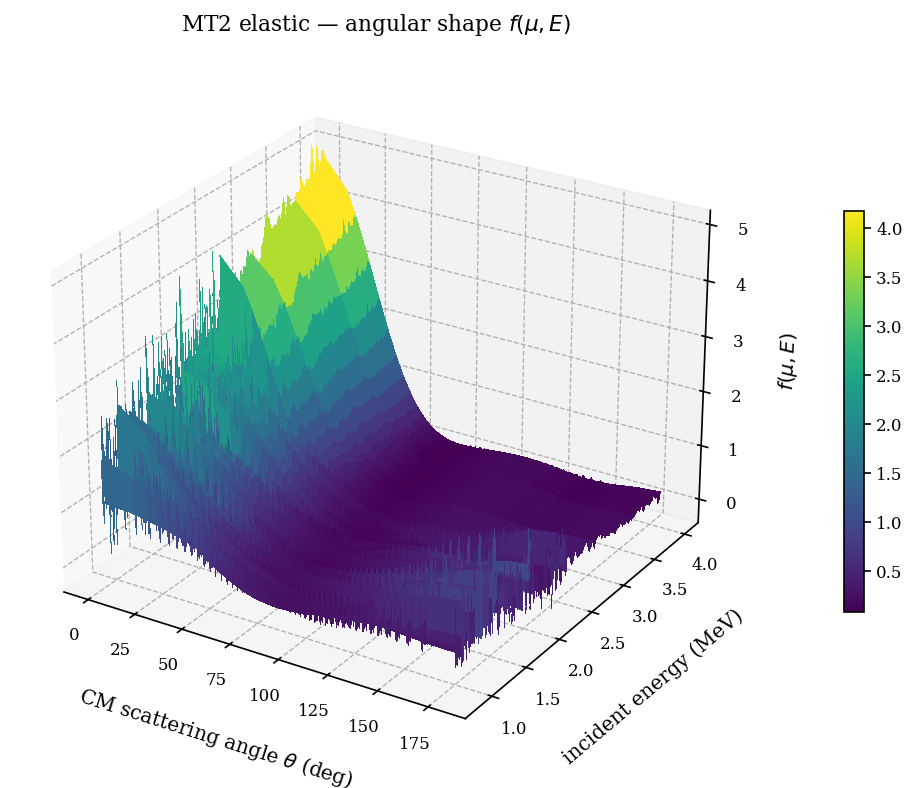

In [5]:
surface3d(F_x, r"$f(\mu, E)$", rf"MT{MT} elastic — angular shape $f(\mu,E)$",
          cmap="viridis")

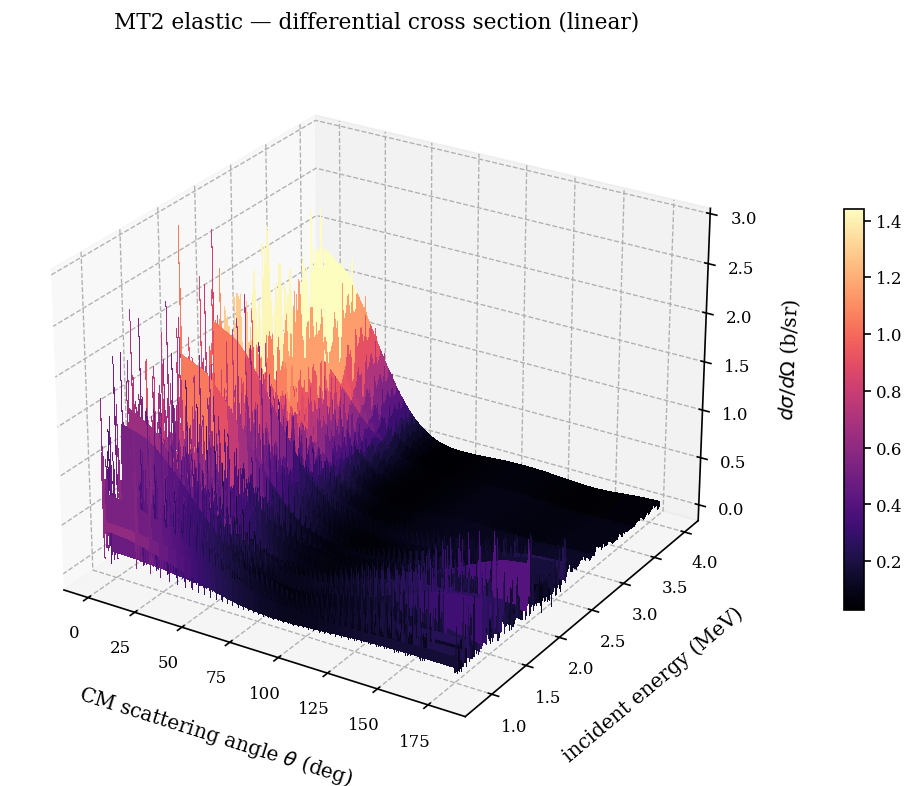

In [6]:
surface3d(DCS_x, r"$d\sigma/d\Omega$ (b/sr)",
          f"MT{MT} elastic — differential cross section (linear)", cmap="magma")

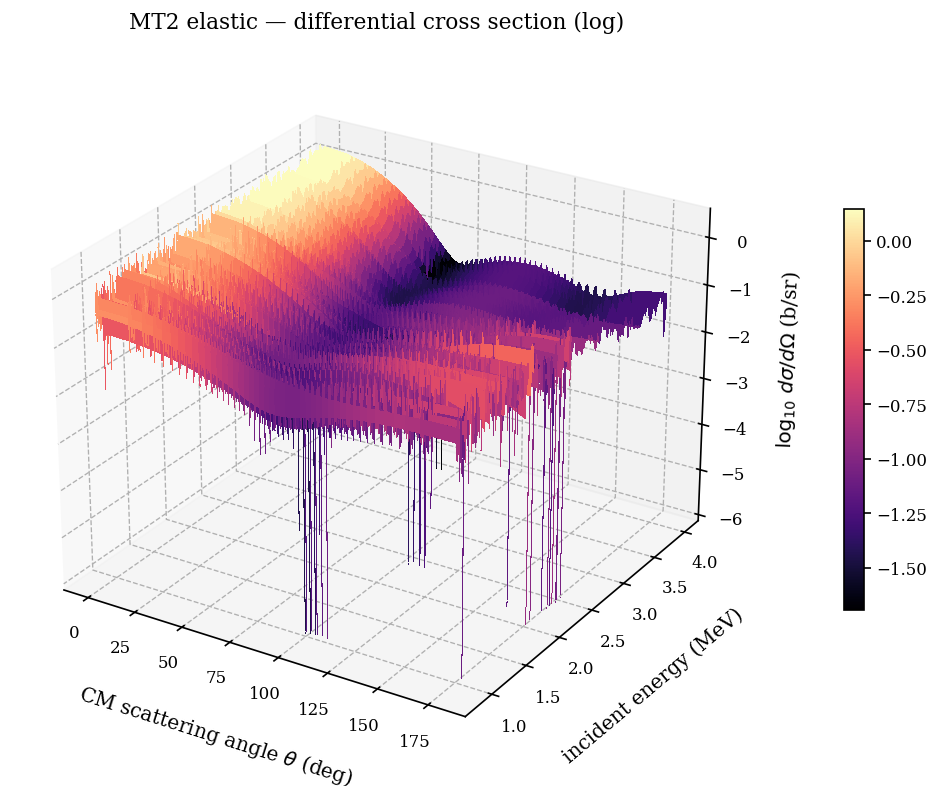

In [7]:
surface3d(DCS_x, r"$\log_{10}\,d\sigma/d\Omega$ (b/sr)",
          f"MT{MT} elastic — differential cross section (log)", cmap="magma", zlog=True)